## DIABETIC FOOT ULCER PREDICTION - DEEP NEURAL NETWORK
    Using Keras Functional API with Multiple Inputs

# Authors: Team 2
    Date: Spring 2026
    Version: TBD

    Architecture:
    - Multiple Input Branches (Functional API)
    - Branch 1: Numerical features (9 inputs) → Dense layers
    - Branch 2: Binary features (22 inputs) → Dense layers
    - Merged → Deep layers → Single output (ulcer probability)

    Features:
    - Class imbalance handling (SMOTE + class weights)
    - Dropout for regularization
    - Batch normalization
    - Early stopping
    - Learning rate scheduling
    - Model checkpointing

    Performance Target: ROC-AUC > 0.78 (beat scikit-learn baseline)

## Import libraries

In [551]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    roc_auc_score, 
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.utils import plot_model
import warnings
warnings.filterwarnings('ignore')

## Set random seeds for reproducibility

In [552]:
np.random.seed(42)
tf.random.set_seed(42)

# STEP 1: LOAD AND PREPARE DATA

In [553]:
df=pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008\Diabetic_data.csv')

In [554]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [555]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [556]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [557]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Display missing values
    Replace ? with Nan for clarity

In [558]:
df_clean = df.replace("?", np.nan)

missing_table = (
    df_clean.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

display(missing_table.style)

,column,missing_count
0,encounter_id,0
1,patient_nbr,0
2,race,2273
3,gender,0
4,age,0
5,weight,98569
6,admission_type_id,0
7,discharge_disposition_id,0
8,admission_source_id,0
9,time_in_hospital,0


## Define outcome (ICD-9 code 707 - chronic ulcers)

In [559]:
df['has_foot_ulcer'] = df[['diag_1', 'diag_2', 'diag_3']].astype(str).apply(
    lambda row: any('707' in val for val in row), axis=1
).astype(int)

In [560]:
df['has_foot_ulcer'].value_counts()

has_foot_ulcer
0    98261
1     3505
Name: count, dtype: int64

## Feature Engineering
    NOTE: RangeIndex: 101766 entries, 0 to 101765
    Variable uses from dataset
    
    IDs are not needed
     0   encounter_id              101766 non-null  int64
     1   patient_nbr               101766 non-null  int64
    
     Sociodemographics
     2   race                      101766 non-null  str  - convert to caucasian and non-caucasian
     3   gender                    101766 non-null  str  - convert to integer
     4   age                       101766 non-null  str  - convert to mean of range
     5   weight                    101766 non-null  str  - 98569 missing, excluded
     
    IDs are not needed
     6   admission_type_id         101766 non-null  int64
     7   discharge_disposition_id  101766 non-null  int64
     8   admission_source_id       101766 non-null  int64

     Healthcare Utilization
     9   time_in_hospital          101766 non-null  int64

     Sociodemographics
     10  payer_code                101766 non-null  str  - 40256 missing, excluded

     Healthcare Utilization
     11  medical_specialty         101766 non-null  str  - 49949 missing, excluded

     Medical Complexity
     12  num_lab_procedures        101766 non-null  int64
     13  num_procedures            101766 non-null  int64
     14  num_medications           101766 non-null  int64

     Healthcare Utilization
     15  number_outpatient         101766 non-null  int64
     16  number_emergency          101766 non-null  int64
     17  number_inpatient          101766 non-null  int64

     Diagnoses from which to find DFU
     18  diag_1                    101766 non-null  str  
     19  diag_2                    101766 non-null  str  
     20  diag_3                    101766 non-null  str  

     Medical Complexity
     21  number_diagnoses          101766 non-null  int64

     Labs
     22  max_glu_serum             5346 non-null    str  - 96420 missing, kept because clinically important
     23  A1Cresult                 17018 non-null   str  - 84748 missing, kept because clinically important

      Medications - very commonly used oral medication, kept for model
     24  metformin                 101766 non-null  str  

     Medications - not kept for model
     25  repaglinide               101766 non-null  str  
     26  nateglinide               101766 non-null  str  
     27  chlorpropamide            101766 non-null  str  
     28  glimepiride               101766 non-null  str  
     29  acetohexamide             101766 non-null  str  
     30  glipizide                 101766 non-null  str  
     31  glyburide                 101766 non-null  str  
     32  tolbutamide               101766 non-null  str  
     33  pioglitazone              101766 non-null  str  
     34  rosiglitazone             101766 non-null  str  
     35  acarbose                  101766 non-null  str  
     36  miglitol                  101766 non-null  str  
     37  troglitazone              101766 non-null  str  
     38  tolazamide                101766 non-null  str  
     39  examide                   101766 non-null  str  
     40  citoglipton               101766 non-null  str  

     Medications - very commonly used, kept for model
     41  insulin                   101766 non-null  str  

     Medications - not kept for model
     42  glyburide-metformin       101766 non-null  str  
     43  glipizide-metformin       101766 non-null  str  
     44  glimepiride-pioglitazone  101766 non-null  str  
     45  metformin-rosiglitazone   101766 non-null  str  
     46  metformin-pioglitazone    101766 non-null  str  

     Medications
     47  change                    101766 non-null  str  
     48  diabetesMed               101766 non-null  str  

     Healthcare utilization
     49  readmitted                101766 non-null  str  
    

#### SocioDemographics

In [561]:
df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [562]:
df['race_caucasian'] = (df['race'] == 'Caucasian').astype(int)
df['race_caucasian'].value_counts()

race_caucasian
1    76099
0    25667
Name: count, dtype: int64

In [563]:
df['gender_male'] = (df['gender'] == 'Male').astype(int)
df['gender_male'].value_counts()

gender_male
0    54711
1    47055
Name: count, dtype: int64

In [564]:
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_mapping)
df['age_numeric'].describe()

count    101766.000000
mean         65.967022
std          15.940838
min           5.000000
25%          55.000000
50%          65.000000
75%          75.000000
max          95.000000
Name: age_numeric, dtype: float64

#### Labs

In [565]:
df['a1c_tested'] = (~df['A1Cresult'].isna()).astype(int)
df['a1c_high'] = (df['A1Cresult'] == '>8').astype(int)
df['a1c_moderate'] = (df['A1Cresult'] == '>7').astype(int)
df['glucose_tested'] = (~df['max_glu_serum'].isna()).astype(int)
df['glucose_high'] = (df['max_glu_serum'] == '>200').astype(int)

df[['a1c_tested',
    'a1c_high',
    'a1c_moderate',
    'glucose_tested',
    'glucose_high']].sum()

a1c_tested        17018
a1c_high           8216
a1c_moderate       3812
glucose_tested     5346
glucose_high       1485
dtype: int64

#### Medications

In [566]:
df['on_metformin'] = df['metformin'].apply(lambda x: 1 if x in ['Up', 'Steady', 'Down'] else 0)
df['on_insulin'] = df['insulin'].apply(lambda x: 1 if x in ['Up', 'Steady', 'Down'] else 0)
df['medication_changed'] = (df['change'] == 'Ch').astype(int)
df['on_diabetes_med'] = (df['diabetesMed'] == 'Yes').astype(int)

df[['on_metformin',
    'on_insulin',
    'medication_changed',
    'on_diabetes_med']].sum()

on_metformin          19988
on_insulin            54383
medication_changed    47011
on_diabetes_med       78363
dtype: int64

#### Healthcare utilization

In [567]:
df['long_hospital_stay'] = (df['time_in_hospital'] >= 7).astype(int)
df['had_emergency_visit'] = (df['number_emergency'] > 0).astype(int)
df['had_outpatient_visit'] = (df['number_outpatient'] > 0).astype(int)
df['had_previous_inpatient'] = (df['number_inpatient'] > 0).astype(int)
df['multiple_inpatient'] = (df['number_inpatient'] >= 2).astype(int)
df['readmit_30d'] = (df['readmitted'] =='<30').astype(int)

df[['long_hospital_stay',
    'had_emergency_visit',
    'had_outpatient_visit',
    'had_previous_inpatient',
    'multiple_inpatient',
    'readmit_30d']].sum()

long_hospital_stay        21149
had_emergency_visit       11383
had_outpatient_visit      16739
had_previous_inpatient    34136
multiple_inpatient        14615
readmit_30d               11357
dtype: int64

#### Disease severity

In [568]:
df['high_lab_procedures'] = (df['num_lab_procedures'] >= 50).astype(int)
df['had_procedures'] = (df['num_procedures'] > 0).astype(int)
df['high_num_medications'] = (df['num_medications'] >= 15).astype(int)
df['many_medications'] = (df['num_medications'] >= 10).astype(int)
df['high_comorbidity'] = (df['number_diagnoses'] >= 8).astype(int)

df[['high_lab_procedures',
    'had_procedures',
    'high_num_medications',
    'many_medications',
    'high_comorbidity']].sum()

high_lab_procedures     39156
had_procedures          55114
high_num_medications    52313
many_medications        81251
high_comorbidity        60205
dtype: int64

#### Diabetest Complications (ICD codes 250.7, 250.8, 250.9)

In [569]:
df['has_diabetic_complication'] = df[['diag_1', 'diag_2', 'diag_3']].astype(str).apply(
    lambda row: any('250.7' in val or '250.8' in val or '250.9' in val for val in row), axis=1
).astype(int)

df['has_gangrene'] = df[['diag_1', 'diag_2', 'diag_3']].astype(str).apply(
    lambda row: any('785' in val for val in row), axis=1
).astype(int)

df[['has_diabetic_complication', 'has_gangrene']].sum()

has_diabetic_complication    4999
has_gangrene                 1001
dtype: int64

## Prepare features (separate into continuous/numerical and binary/categorical)

#### Numerical features

In [570]:
numerical_features = [
    # sociodemographics
    'age_numeric',

    # Healthcare utilization - primary variables
    'time_in_hospital',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',

    # Disease severity - primary variables
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'
]

#### Binary Features

In [571]:
binary_features = [
    # Sociodemographics
    'race_caucasian',
    'gender_male',

    # Labs
    'a1c_tested',
    'a1c_high',
    'a1c_moderate',
    'glucose_tested',
    'glucose_high',

    # Medications
    'on_metformin',
    'on_insulin',
    'on_diabetes_med',
    'medication_changed',
    
    # Healthcare utilization
    'long_hospital_stay',
    'had_emergency_visit',
    'had_outpatient_visit',
    'had_previous_inpatient',
    'multiple_inpatient',
    'readmit_30d',

    # Disease severity
    'high_lab_procedures',
    'had_procedures',    
    'high_num_medications',
    'many_medications',
    'high_comorbidity',

    # Diabetest Complications
    'has_diabetic_complication',
    'has_gangrene',
    'has_foot_ulcer'    
]

### Impute missing values directly into the DataFrame

In [572]:
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].median())
df[binary_features] = df[binary_features].fillna(0)

print("Updated numerical features:")
display(df[numerical_features].describe())

print("Updated binary feature counts:")
display(df[binary_features].sum())

Updated numerical features:


,age_numeric,time_in_hospital,number_outpatient,number_emergency,number_inpatient,num_lab_procedures,num_procedures,num_medications,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,65.967022,4.395987,0.369357,0.197836,0.635566,43.095641,1.339730,16.021844,7.422607
std,15.940838,2.985108,1.267265,0.930472,1.262863,19.674362,1.705807,8.127566,1.933600
min,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,55.000000,2.000000,0.000000,0.000000,0.000000,31.000000,0.000000,10.000000,6.000000
50%,65.000000,4.000000,0.000000,0.000000,0.000000,44.000000,1.000000,15.000000,8.000000
75%,75.000000,6.000000,0.000000,0.000000,1.000000,57.000000,2.000000,20.000000,9.000000
max,95.000000,14.000000,42.000000,76.000000,21.000000,132.000000,6.000000,81.000000,16.000000


Updated binary feature counts:


race_caucasian               76099
gender_male                  47055
a1c_tested                   17018
a1c_high                      8216
a1c_moderate                  3812
glucose_tested                5346
glucose_high                  1485
on_metformin                 19988
on_insulin                   54383
on_diabetes_med              78363
medication_changed           47011
long_hospital_stay           21149
had_emergency_visit          11383
had_outpatient_visit         16739
had_previous_inpatient       34136
multiple_inpatient           14615
readmit_30d                  11357
high_lab_procedures          39156
had_procedures               55114
high_num_medications         52313
many_medications             81251
high_comorbidity             60205
has_diabetic_complication     4999
has_gangrene                  1001
has_foot_ulcer                3505
dtype: int64

##### Outliers detection

In [573]:
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1

outliers = (df[numerical_features] < (Q1 - 1.5 * IQR)) | \
           (df[numerical_features] > (Q3 + 1.5 * IQR))

outlier_summary = pd.DataFrame({
    'num_outliers': outliers.sum(),
    'percent_outliers': (outliers.sum() / len(df)).round(3)
})

outlier_summary

,num_outliers,percent_outliers
age_numeric,852,0.008
time_in_hospital,2252,0.022
number_outpatient,16739,0.164
number_emergency,11383,0.112
number_inpatient,7049,0.069
num_lab_procedures,143,0.001
num_procedures,4954,0.049
num_medications,2557,0.025
number_diagnoses,281,0.003


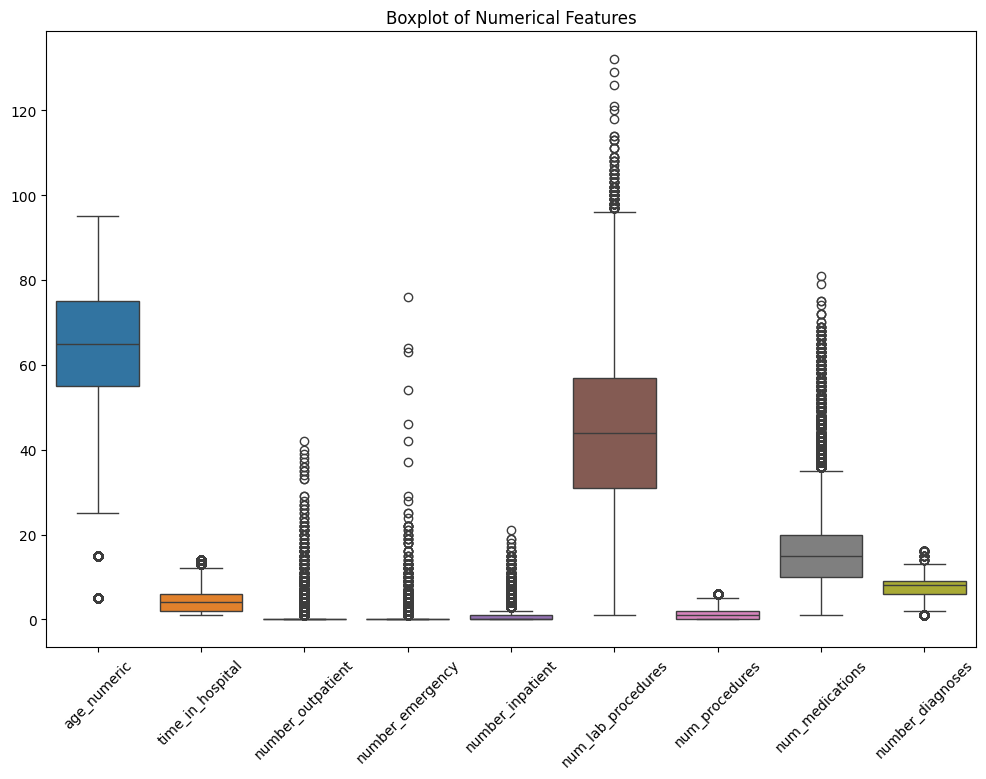

In [574]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

Outliers are seen more for factors with missing values that were imputed. Insulin (373 missing values), and     TricepsThickness (227 missing values) have the most outliers.

#### Check correlation

In [575]:
num_corr = df[numerical_features +  ['has_foot_ulcer']].corr()
num_corr

,age_numeric,time_in_hospital,number_outpatient,number_emergency,number_inpatient,num_lab_procedures,num_procedures,num_medications,number_diagnoses,has_foot_ulcer
age_numeric,1.000000,0.107515,0.023724,-0.087291,-0.042861,0.020770,-0.030104,0.041847,0.242597,0.011529
time_in_hospital,0.107515,1.000000,-0.008916,-0.009681,0.073623,0.318450,0.191472,0.466135,0.220186,0.094355
number_outpatient,0.023724,-0.008916,1.000000,0.091459,0.107338,-0.007602,-0.024819,0.045197,0.094152,0.043048
number_emergency,-0.087291,-0.009681,0.091459,1.000000,0.266559,-0.002279,-0.038179,0.013180,0.055539,0.004203
number_inpatient,-0.042861,0.073623,0.107338,0.266559,1.000000,0.039231,-0.066236,0.064194,0.104710,0.036411
num_lab_procedures,0.020770,0.318450,-0.007602,-0.002279,0.039231,1.000000,0.058066,0.268161,0.152773,0.003694
num_procedures,-0.030104,0.191472,-0.024819,-0.038179,-0.066236,0.058066,1.000000,0.385767,0.073734,0.011285
num_medications,0.041847,0.466135,0.045197,0.013180,0.064194,0.268161,0.385767,1.000000,0.261526,0.033537
number_diagnoses,0.242597,0.220186,0.094152,0.055539,0.104710,0.152773,0.073734,0.261526,1.000000,0.055757
has_foot_ulcer,0.011529,0.094355,0.043048,0.004203,0.036411,0.003694,0.011285,0.033537,0.055757,1.000000


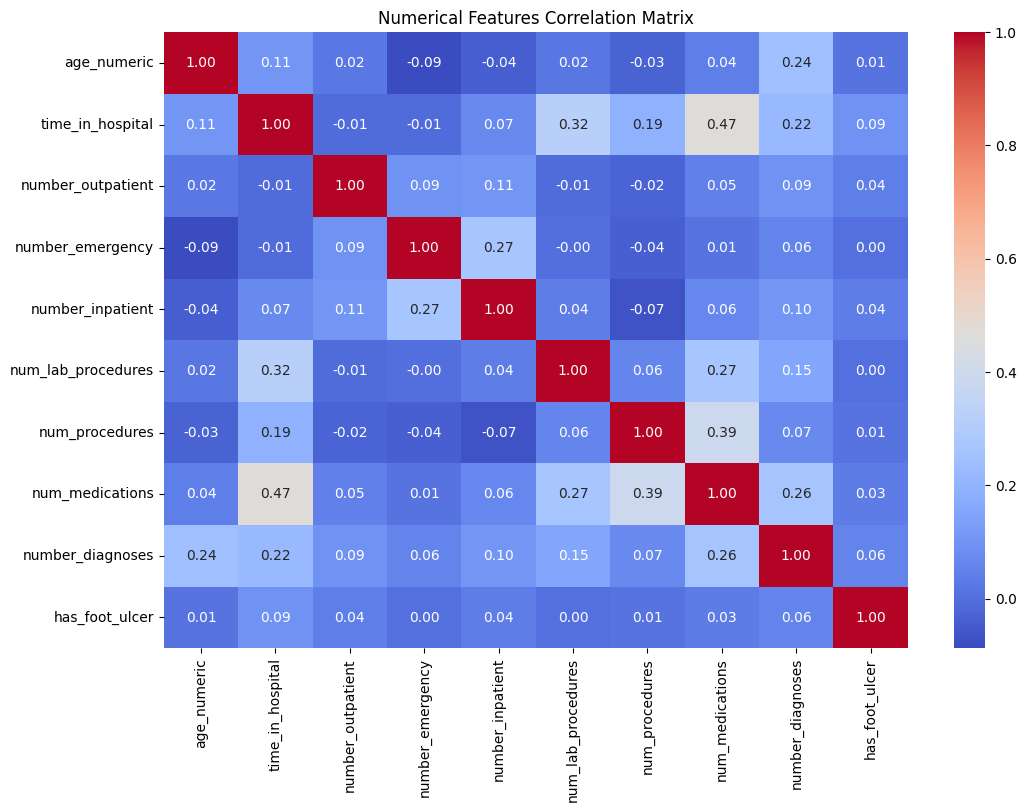

In [576]:
plt.figure(figsize=(12, 8))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numerical Features Correlation Matrix")
plt.show()

In [577]:
bin_corr = df[binary_features].corr()
bin_corr

,race_caucasian,gender_male,a1c_tested,a1c_high,a1c_moderate,glucose_tested,glucose_high,on_metformin,on_insulin,on_diabetes_med,...,multiple_inpatient,readmit_30d,high_lab_procedures,had_procedures,high_num_medications,many_medications,high_comorbidity,has_diabetic_complication,has_gangrene,has_foot_ulcer
race_caucasian,1.000000,0.055503,-0.034609,-0.041926,0.013876,0.056019,0.028594,0.010439,-0.052970,-0.007991,...,-0.002508,0.007144,0.017661,0.010427,0.051708,0.051707,0.098678,-0.011848,-0.008147,-0.001115
gender_male,0.055503,1.000000,0.019654,0.021707,0.009693,-0.002200,-0.001091,0.001680,0.001033,0.015932,...,-0.010495,-0.002898,-0.016451,0.033469,-0.035321,-0.036068,-0.002039,0.028957,0.014809,0.024786
a1c_tested,-0.034609,0.019654,1.000000,0.661331,0.440226,-0.070344,-0.038940,0.041257,0.091731,0.069683,...,-0.051809,-0.018665,0.215241,-0.052769,0.011320,-0.001007,-0.000101,0.050323,0.003897,0.025972
a1c_high,-0.041926,0.021707,0.661331,1.000000,-0.058462,-0.041164,-0.025234,0.042789,0.117754,0.093123,...,-0.027249,-0.012131,0.146921,-0.042753,-0.004290,-0.013193,-0.035194,0.047300,0.002626,0.028883
a1c_moderate,0.013876,0.009693,0.440226,-0.058462,1.000000,-0.031838,-0.016238,0.019054,0.009845,0.016804,...,-0.026186,-0.006971,0.088205,-0.016876,0.017026,0.008573,0.022721,0.018616,0.005508,0.013822
glucose_tested,0.056019,-0.002200,-0.070344,-0.041164,-0.031838,1.000000,0.516801,-0.029714,-0.005639,-0.019216,...,0.020251,0.009007,-0.099848,-0.054034,-0.003536,-0.000143,-0.046749,0.012104,0.006880,-0.003412
glucose_high,0.028594,-0.001091,-0.038940,-0.025234,-0.016238,0.516801,1.000000,-0.013133,0.023234,0.012561,...,0.009518,0.005016,-0.055981,-0.025202,0.008466,0.010491,-0.021094,-0.000359,0.003648,-0.001414
on_metformin,0.010439,0.001680,0.041257,0.042789,0.019054,-0.029714,-0.013133,1.000000,-0.033195,0.270176,...,-0.067323,-0.022909,-0.033689,-0.030182,0.046080,0.057422,-0.065816,-0.000785,-0.009175,-0.000328
on_insulin,-0.052970,0.001033,0.091731,0.117754,0.009845,-0.005639,0.023234,-0.033195,1.000000,0.585464,...,0.062905,0.033278,0.083988,-0.003776,0.182936,0.156839,0.088847,0.045262,0.014387,0.035103
on_diabetes_med,-0.007991,0.015932,0.069683,0.093123,0.016804,-0.019216,0.012561,0.270176,0.585464,1.000000,...,0.023837,0.027125,0.036699,-0.023925,0.159101,0.176838,0.025191,0.018110,-0.000190,0.020493


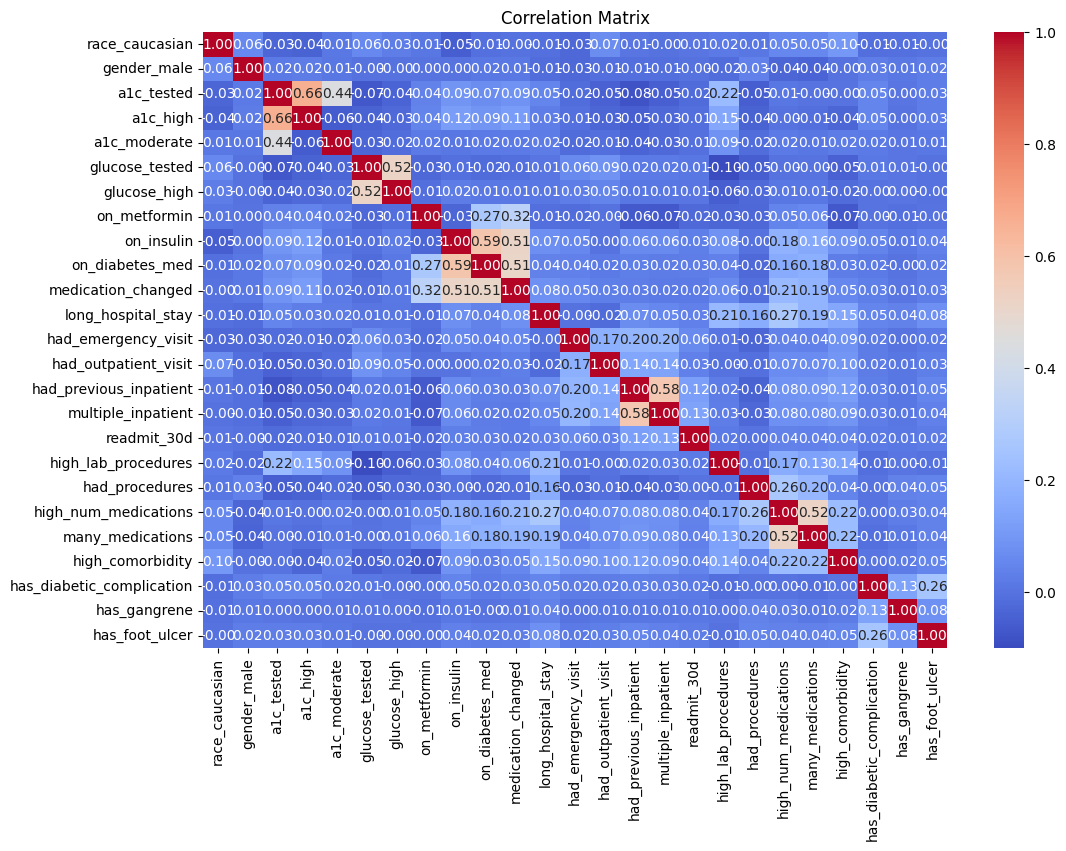

In [578]:
plt.figure(figsize=(12, 8))
sns.heatmap(bin_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [579]:
combined = df[numerical_features + binary_features]
corr = combined.corr()
corr

,age_numeric,time_in_hospital,number_outpatient,number_emergency,number_inpatient,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_caucasian,...,multiple_inpatient,readmit_30d,high_lab_procedures,had_procedures,high_num_medications,many_medications,high_comorbidity,has_diabetic_complication,has_gangrene,has_foot_ulcer
age_numeric,1.000000,0.107515,0.023724,-0.087291,-0.042861,0.020770,-0.030104,0.041847,0.242597,0.169892,...,-0.018110,0.017634,0.023382,-0.023353,0.045649,0.084461,0.187476,-0.015385,-0.004235,0.011529
time_in_hospital,0.107515,1.000000,-0.008916,-0.009681,0.073623,0.318450,0.191472,0.466135,0.220186,-0.005921,...,0.068162,0.044199,0.275550,0.187095,0.357232,0.272773,0.198498,0.049174,0.040114,0.094355
number_outpatient,0.023724,-0.008916,1.000000,0.091459,0.107338,-0.007602,-0.024819,0.045197,0.094152,0.058498,...,0.100312,0.018893,0.011147,-0.006797,0.053879,0.052173,0.088008,0.028544,0.013143,0.043048
number_emergency,-0.087291,-0.009681,0.091459,1.000000,0.266559,-0.002279,-0.038179,0.013180,0.055539,-0.022497,...,0.191240,0.060747,-0.000314,-0.025149,0.020424,0.022918,0.054256,0.015393,-0.001395,0.004203
number_inpatient,-0.042861,0.073623,0.107338,0.266559,1.000000,0.039231,-0.066236,0.064194,0.104710,-0.001808,...,0.795851,0.165147,0.028112,-0.030789,0.080483,0.079436,0.095832,0.027499,0.010628,0.036411
num_lab_procedures,0.020770,0.318450,-0.007602,-0.002279,0.039231,1.000000,0.058066,0.268161,0.152773,-0.022991,...,0.040426,0.020364,0.768674,0.007967,0.211074,0.167334,0.138535,-0.008835,0.010756,0.003694
num_procedures,-0.030104,0.191472,-0.024819,-0.038179,-0.066236,0.058066,1.000000,0.385767,0.073734,0.030016,...,-0.059761,-0.012227,0.028079,0.722593,0.253645,0.182884,0.056471,-0.020479,0.036361,0.011285
num_medications,0.041847,0.466135,0.045197,0.013180,0.064194,0.268161,0.385767,1.000000,0.261526,0.055907,...,0.062875,0.038432,0.211013,0.330297,0.737274,0.570814,0.231103,-0.003028,0.028191,0.033537
number_diagnoses,0.242597,0.220186,0.094152,0.055539,0.104710,0.152773,0.073734,0.261526,1.000000,0.108805,...,0.101301,0.049524,0.149662,0.057080,0.244704,0.261958,0.877683,0.002948,0.023789,0.055757
race_caucasian,0.169892,-0.005921,0.058498,-0.022497,-0.001808,-0.022991,0.030016,0.055907,0.108805,1.000000,...,-0.002508,0.007144,0.017661,0.010427,0.051708,0.051707,0.098678,-0.011848,-0.008147,-0.001115


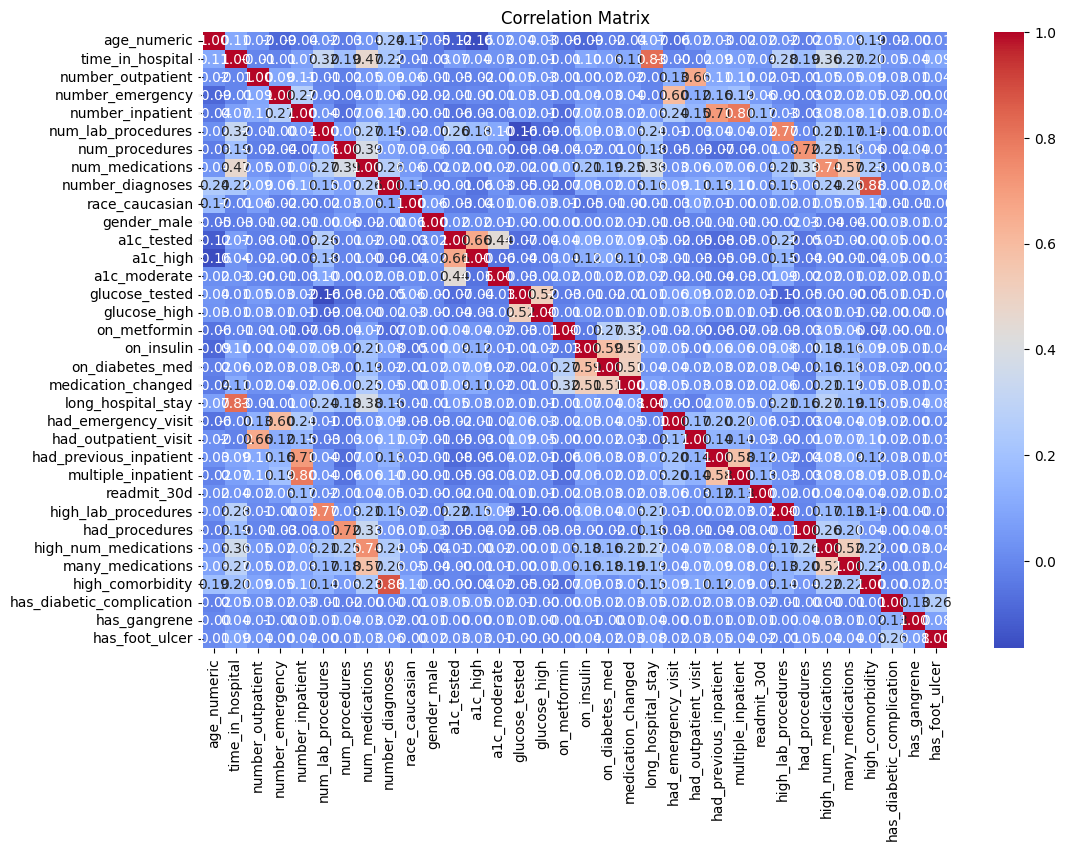

In [580]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Check imbalanced data

In [581]:
print(df['has_foot_ulcer'].value_counts())
df['has_foot_ulcer'].value_counts(normalize=True) * 100

has_foot_ulcer
0    98261
1     3505
Name: count, dtype: int64


has_foot_ulcer
0    96.555824
1     3.444176
Name: proportion, dtype: float64

### Address Feature Scale Mismatch by MinMaxScaler
#### Scale Numerical data using MinMaxScaler to 0-1 range, and covert to datafame for plotting histograams
#### keep binary data unchanged (0/1)
#### Assign outcome variable

In [582]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_numerical = scaler.fit_transform(df[numerical_features])
X_numerical_df = pd.DataFrame(X_numerical, columns=numerical_features)

X_binary = df[binary_features].values

y = df['has_foot_ulcer'].values

X_numerical, X_binary, y

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.11111111, 0.15384615, 0.        , ..., 0.        , 0.2125    ,
         0.53333333],
        [0.22222222, 0.07692308, 0.04761905, ..., 0.83333333, 0.15      ,
         0.33333333],
        ...,
        [0.77777778, 0.        , 0.02380952, ..., 0.        , 0.1       ,
         0.8       ],
        [0.88888889, 0.69230769, 0.        , ..., 0.33333333, 0.25      ,
         0.53333333],
        [0.77777778, 0.38461538, 0.        , ..., 0.5       , 0.025     ,
         0.53333333]]),
 array([[1, 0, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [1, 1, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0]], dtype=int64),
 array([0, 0, 0, ..., 0, 0, 0]))

#### Examine plots
    Histogram

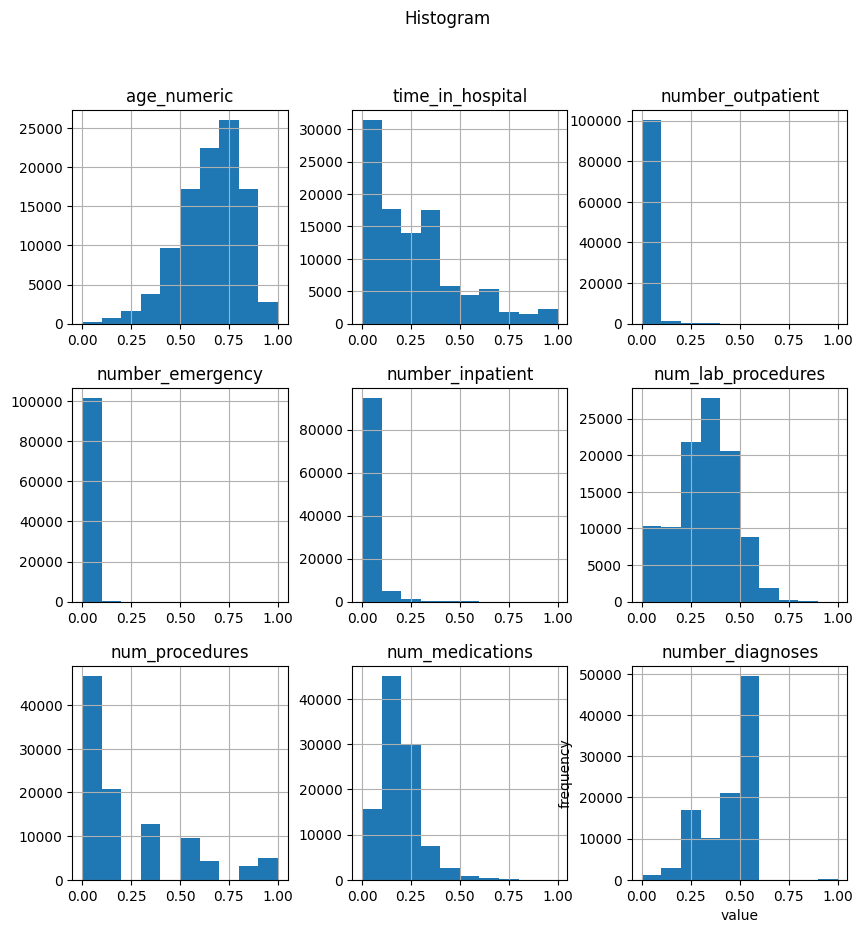

In [583]:
X_numerical_df.hist(figsize=(10, 10))
plt.suptitle("Histogram")
plt.ylabel("frequency")
plt.xlabel("value")
plt.show()

# Boxplot 

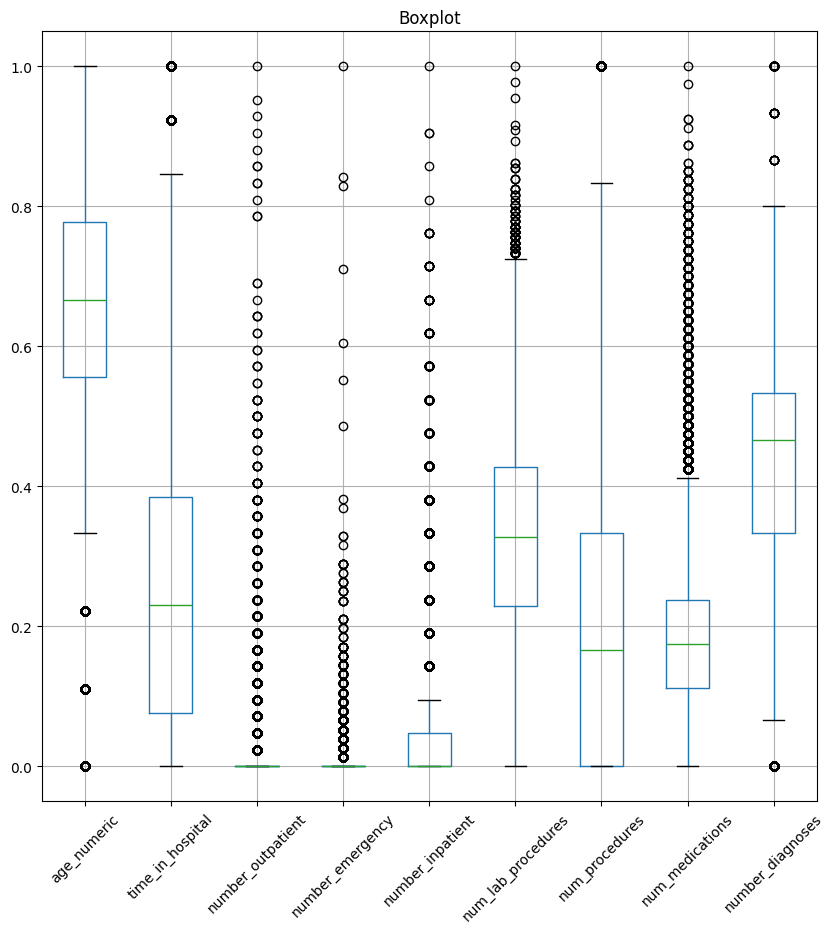

In [584]:
plt.figure(figsize=(10, 10))
X_numerical_df.boxplot()
plt.title("Boxplot")
plt.xticks(rotation=45)
plt.show()

In [585]:
output = df

import numpy as np

output['A1Cresult'] = output['A1Cresult'].replace(['None', '?'], np.nan)
output['max_glu_serum'] = output['max_glu_serum'].replace(['None', '?'], np.nan)
output['A1Cresult'] = output['A1Cresult'].fillna('NoTest')
output['max_glu_serum'] = output['max_glu_serum'].fillna('NoTest')


output['A1Cresult'] = output['A1Cresult'].map({
    'NoTest': 0,
    'Norm': 1,
    '>7': 2,
    '>8': 3
})

output['max_glu_serum'] = output['max_glu_serum'].map({
    'NoTest': 0,
    'Norm': 1,
    '>200': 2,
    '>300': 3
})

output['race'] = output['race'].map({
    'Caucasian': 0,
    'AfricanAmerican': 1,
    'Hispanic': 2,
    'Asian': 3,
    'Other': 4,
    '?': 5
})

output['gender'] = output['gender'].map({
    'Male': 0,
    'Female': 1,
    'Unknown/Invalid': 2
})

output['age'] = output['age'].map({
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
})

output['diabetesMed'] = output['diabetesMed'].map({
    'No': 0,
    'Yes': 1
})

output['change'] = output['change'].map({
    'No': 0,
    'Ch': 1
})

output['metformin'] = output['metformin'].map({
    'No': 0,
    'Down': 1,
    'Steady': 2,
    'Up': 3
})
output['insulin'] = output['insulin'].map({
    'No': 0,
    'Down': 1,
    'Steady': 2,
    'Up': 3
})


# Drop the unimpoortant categories that cannot have impact on the Model for classifying a DFU or not.
output = output.drop(columns=["encounter_id", "patient_nbr", "admission_type_id", "discharge_disposition_id", "admission_source_id", "num_procedures", "number_outpatient"])
# Drop the categories that have too many missing values 
output = output.drop(columns=["weight","payer_code", "medical_specialty"])
# Drop the categories have no impact on a Diabetic foot ulcer
output = output.drop(columns=["repaglinide", "nateglinide","chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide","tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", "readmitted"])
output = output.drop(columns=["race_caucasian", "gender_male", "age_numeric", "a1c_tested", "a1c_high", "a1c_moderate", "glucose_tested", "glucose_high", "on_metformin", "on_insulin", "tolazamide", "examide", "citoglipton", "diag_1","diag_2", "diag_3"])
output = output.drop(columns=["glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone", "medication_changed", "on_diabetes_med", "long_hospital_stay", "had_emergency_visit", "had_outpatient_visit"])
output = output.drop(columns=["had_previous_inpatient", "multiple_inpatient", "readmit_30d", "high_lab_procedures", "had_procedures", "high_num_medications", "many_medications", "high_comorbidity", "has_diabetic_complication", "has_gangrene"])

output = output[
    [col for col in output.columns if col not in ['metformin','insulin','change','diabetesMed', 'has_foot_ulcer']]
    + ['diabetesMed','change','metformin','insulin', 'has_foot_ulcer']
]

output.to_csv(r'C:\Users\ryana\Downloads\AI-570-Group-Project\output.csv', index=False)

Values have been scaled 0-1, with outliers within this range